In [1]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris

# metrics
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay                         

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys
from copy import deepcopy
# =====================================


### Principal Components Analysis

**Please Read eigen vector & eigen value. Nots already created**
**singular value decomposition, Yet not studies**
**Please See statequest video PCA**

PCA very old tech and has been rediscovered many times in many fields, so it is also known as the 
- Karhunen-Loève transformation
- The Hotelling transformation, the method of empirical orthogonal functions, 
- singular value decomposition

***Principal components analysis (PCA) is one of a family of techniques for taking high-dimensional data, and using the dependencies between the variables to represent it in a more tractable, lower-dimensional form, without losing too much information.*** 

PCA is one of the simplest and most robust ***ways of doing such dimensionality reduction***.

Principal component analysis can also be viewed as a technique to ***remove multicollinearity in the data***. 

Qus: How to do this ?

In this technique, we **transform the original set of variables** to a new **set of uncorrelated random variables**, called **principal components**. These **new variables are linear combinations of the original variables** and are **derived in decreasing order of importance** so that the **first principal component accounts for as much as possible of the variation in the original data**.

Qus: What our objective in Principial Component ?

p-dimensional vectors, and want to summarize them by projecting down into a q-dimensional subspace.

1. The simplest one is by finding the projections which **maximize the variance**. The first principal 
   component is the direction in space along which projections have the largest variance. 

2. The second principal component is the direction which maximizes variance among all directions **orthogonal 
   to the first**. The kth component is the variance-maximizing direction orthogonal to the previous k −1 components. There are p principal components in all.

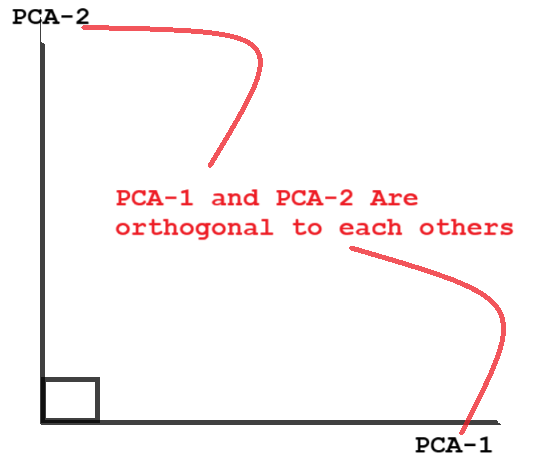


Rather than maximizing variance, it might sound more plausible to look for the projection with the **smallest average (mean-squared) distance between the original vectors and their projections on to the principal components**; this turns out to be equivalent to maximizing the variance.

Qus: How to take smallest average (mean-squared) distance between the original vectors and their projections on to the principal components ?

Before going to do any thong assume ***data have been “centered”, so that every variable has mean 0***.

Properties of cnetered Data: 

If we **write the centered data in a matrix x**, where rows are objects and columns are variables, then 

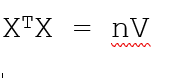

where ***v is the covariance matrix of the data*** & n is scaler quantity



### Qus: Find Projections of vector a on vector b?

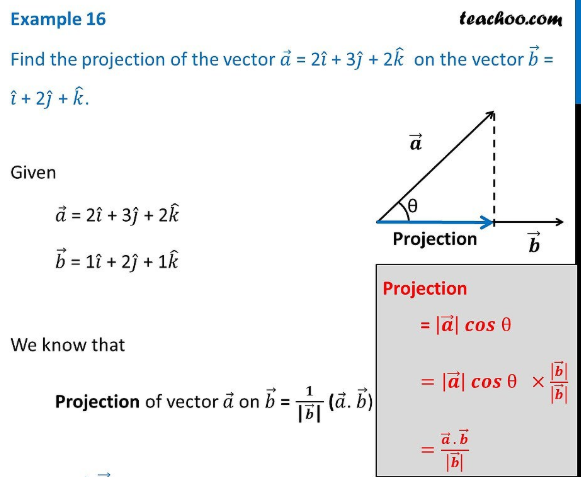

### Method 1: 18.1.1 Minimizing Projection Residuals

So at this point i am not going much deep into math. So basice theory is here


### Method 18.1.2 Maximizing Variance

In [2]:
# Calculate variance from eigen value
def variance_from_eigen(eigenvalues, n_components=None):
    """
    Calculate the variance explained by each component from eigenvalues.

    Parameters:
    eigenvalues (array-like): Eigenvalues of the covariance matrix.
    n_components (int, optional): Number of components to consider. If None, all components are used.

    Returns:
    array: Variance explained by each component.
    """
    if n_components is None:
        n_components = len(eigenvalues)
    
    total_variance = sum(eigenvalues[:n_components])
    variance_explained = [eigenvalue / total_variance for eigenvalue in eigenvalues[:n_components]]
    
    return variance_explained

    

### Methos 1:
**Step by step PCA analysis 2-D vector**

In [3]:
# Step by step PCA analysis 2-D vector
def pca_step_by_step(X, n_components=2):
    # Step 1: Standardize the data    
    print('pca_from_covariance is set to False, standardizing the data')
    # Standardize the data (mean=0, variance=1)
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X_standardized = (X - X_mean) / X_std
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean           
    # Step 2: Compute the covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)
    
    # Step 3: Compute the eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Step 4: Sort the eigenvalues and eigenvectors
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    # Step 5: Select the first n_components principle component eigenvectors
    PCs = sorted_eigenvectors[:, :n_components]    
    # Step 6: Projected Data
    X_pca = np.dot(X_centered, PCs)
    # Step 7: Return the projected data, PCs, eigenvalues, and mean
    return X_pca, PCs, sorted_eigenvalues[:n_components], X_mean    

### you can obtained steage 5 to obtained PC's component by use following formulas

Step 5: Select the first n_components principle component eigenvectors

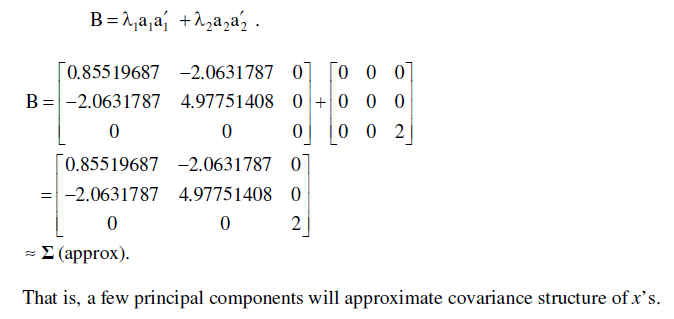



In [4]:
# Example 1 (Principal components from Covariance Matrix) :
covariance_matrix = np.array([[1,-2,0],[-2,5,0],[0,0,2]])
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvectors_transposed = sorted_eigenvectors.T
print("Sorted Eigenvalues:", sorted_eigenvalues)
print("Sorted Eigenvectors:\n", sorted_eigenvectors_transposed)

#Calculate variance
variance_matrix = np.diag(covariance_matrix)
sum_variance = np.sum(variance_matrix)
if sum_variance == np.sum(sorted_eigenvalues):
    print("The sum of the variance matrix is equal to the sum of the eigenvalues.\nMagice Happend!!!!")
    print('that means that the variance matrix is eigenvalues of the covariance matrix')
else:
    print("The sum of the variance matrix is NOT equal to the sum of the eigenvalues.")
# Calculate The proportion of total variance accounted for by the first principal component
proportion_variance_labda_1 = sorted_eigenvalues[0] / sum_variance
print("Proportion of total variance accounted for by the first principal component:", proportion_variance_labda_1)
proportion_variance_labda_2 = sorted_eigenvalues[1] / sum_variance
print("Proportion of total variance accounted for by the second principal component:", proportion_variance_labda_2)
proportion_variance_labda_3 = sorted_eigenvalues[2] / sum_variance
print("Proportion of total variance accounted for by the third principal component:", proportion_variance_labda_3)
proportion_variance_labda_1_2 = (sorted_eigenvalues[0] + sorted_eigenvalues[1]) / sum_variance
print("Proportion of total variance accounted for by the first and second principal components:", proportion_variance_labda_1_2)
# So praprotions of variance due to lambda 1 & 2 are maximum, 
# so we can use them to reduce the dimensionality of the data 
# with little loss of information.
# Just appply this formula to get the proportion of variance


Eigenvalues: [0.17157288 2.         5.82842712]
Eigenvectors:
 [[-0.92387953  0.         -0.38268343]
 [-0.38268343  0.          0.92387953]
 [-0.          1.          0.        ]]
Sorted Eigenvalues: [5.82842712 2.         0.17157288]
Sorted Eigenvectors:
 [[-0.38268343  0.92387953  0.        ]
 [ 0.          0.          1.        ]
 [-0.92387953 -0.38268343 -0.        ]]
The sum of the variance matrix is equal to the sum of the eigenvalues.
Magice Happend!!!!
that means that the variance matrix is eigenvalues of the covariance matrix
Proportion of total variance accounted for by the first principal component: 0.7285533905932737
Proportion of total variance accounted for by the second principal component: 0.25
Proportion of total variance accounted for by the third principal component: 0.02144660940672624
Proportion of total variance accounted for by the first and second principal components: 0.9785533905932737


In [5]:
# Example 2 (Principal components from Covariance Matrix) :
data = {
    "X1 (sweat rate)": [3.7, 5.7, 3.8, 3.2, 3.1, 4.6, 2.4, 7.2, 6.7, 5.4, 3.9, 4.5, 3.5, 4.5, 1.5, 8.5, 4.5, 6.5, 4.1, 5.5],
    "X2 (sodium content)": [48.5, 65.1, 47.2, 53.2, 55.5, 36.1, 24.8, 33.1, 47.4, 54.1, 36.9, 58.8, 27.8, 40.2, 13.5, 56.4, 71.6, 52.8, 44.1, 40.9],
    "X3 (potassium content)": [9.3, 8.0, 10.9, 12.0, 9.7, 7.9, 14.0, 7.6, 8.5, 11.3, 12.7, 12.3, 9.8, 8.4, 10.1, 7.1, 8.2, 10.9, 11.2, 9.4]
}
# Create the DataFrame
df = pd.DataFrame(data)
X_matrix = df.values
# Perform PCA step by step


In [6]:
# X_pca, PCs, sorted_eigenvalues[:n_components], X_mean 
X_pca, PCs, EigenV, X_mean = pca_step_by_step(X_matrix, n_components=3)
sum_variance = np.sum(EigenV)
print("Projected Data (X_pca):\n", X_pca)
print("Principal Components (PCs):\n", PCs)
#print("Eigenvalues:\n", EigenV)
#print("Mean of the original data:\n", X_mean)
proportion_variance_labda_1 = EigenV[0] / sum_variance
print("Proportion of total variance accounted for by the first principal component:", proportion_variance_labda_1)
proportion_variance_labda_1_2 = (EigenV[0] + EigenV[1]) / sum_variance
print("Proportion of total variance accounted for by the first and second principal components:", proportion_variance_labda_1_2)


pca_from_covariance is set to False, standardizing the data
Projected Data (X_pca):
 [[ 3.06622055e+00  1.60110252e-01  1.22820245e+00]
 [ 1.97772029e+01 -1.16970661e+00  7.54225004e-01]
 [ 1.72702162e+00  1.34156546e+00  1.93451355e-01]
 [ 7.65423918e+00  2.90298976e+00  2.00244771e-01]
 [ 1.00120717e+01  1.20241342e+00  1.66266258e+00]
 [-9.22603766e+00 -2.15795936e+00  9.89578435e-01]
 [-2.07958291e+01  3.49086282e+00 -1.00309142e+00]
 [-1.20799790e+01 -4.05385361e+00 -1.03788397e+00]
 [ 2.14389025e+00 -2.27319918e+00 -7.91280657e-01]
 [ 8.68489562e+00  1.11641859e+00 -1.17303989e+00]
 [-8.60254332e+00  2.20930588e+00 -1.18027158e+00]
 [ 1.33019993e+01  2.69929292e+00 -8.95799479e-01]
 [-1.76229524e+01 -4.13999226e-01  5.89047358e-01]
 [-5.15269514e+00 -1.47453273e+00  8.85613370e-01]
 [-3.20088112e+01  2.20419529e-01  1.69565539e+00]
 [ 1.12606567e+01 -3.97296503e+00 -1.23328171e+00]
 [ 2.61992218e+01  2.68395160e-02  1.78181987e+00]
 [ 7.45468125e+00  8.94800086e-02 -1.87444545e+0

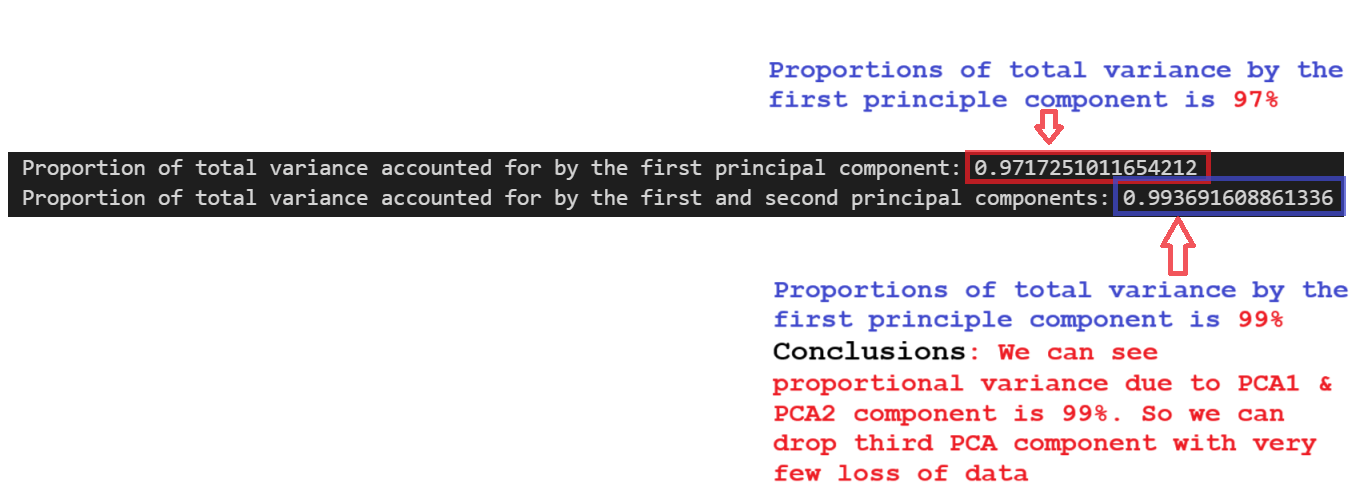


### Method 2:
**Numpy SVD method to obtained PCA's component**

In [7]:
# PCA by using numpy svd
def pca_from_svd(X, n_components=2):
    # Step 1: Standardize the data
    print('pca_from_svd is set to True, standardizing the data')
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean
    
    # Step 2: Perform Singular Value Decomposition (SVD)
    U, S, VT = np.linalg.svd(X_centered, full_matrices=False)
    
    # Step 3: Select the first n_components principal components
    PCs = VT[:n_components].T
    
    # Step 4: Project the data onto the principal components
    X_pca = np.dot(X_centered, PCs)
    
    return X_pca, PCs, S[:n_components], X_mean


In [8]:
# 3D synthetic dataset
np.random.seed(4)
m = 60
w1, w2 = 0.1, 0.3
noise = 0.1

angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
X = np.empty((m, 3))
X[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * np.random.randn(m) / 2
X[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m) / 2
X[:, 2] = X[:, 0] * w1 + X[:, 1] * w2 + noise * np.random.randn(m)


In [9]:
X_pca, PCs, Eigen, X_mean = pca_step_by_step(X, n_components=3)
x_pca_svd, pcs_svd, Sx, X_mean = pca_from_svd(X, n_components=3)
# print("Projected Data (X_pca):\n", X_pca)
print("Principal Components (PCs):\n", PCs)
# print("Eigenvalues:\n", Eigen)
# print("Mean of the original data:\n", X_mean)
# print("Projected Data (x_pca_svd):\n", x_pca_svd)
print("Principal Components (pcs_svd):\n", pcs_svd)
# print("Singular Values (Sx):\n", Sx)


pca_from_covariance is set to False, standardizing the data
pca_from_svd is set to True, standardizing the data
Principal Components (PCs):
 [[-0.93636116 -0.34027485 -0.08626012]
 [-0.29854881  0.90119108 -0.31420255]
 [-0.18465208  0.2684542   0.94542898]]
Principal Components (pcs_svd):
 [[ 0.93636116 -0.34027485 -0.08626012]
 [ 0.29854881  0.90119108 -0.31420255]
 [ 0.18465208  0.2684542   0.94542898]]


### Obtained Variance contributions by Indivisual Regressor variabls

In [10]:
variance_from_eigen(Eigen, n_components=None)

[0.8424860713752884, 0.14631839305402256, 0.011195535570688924]

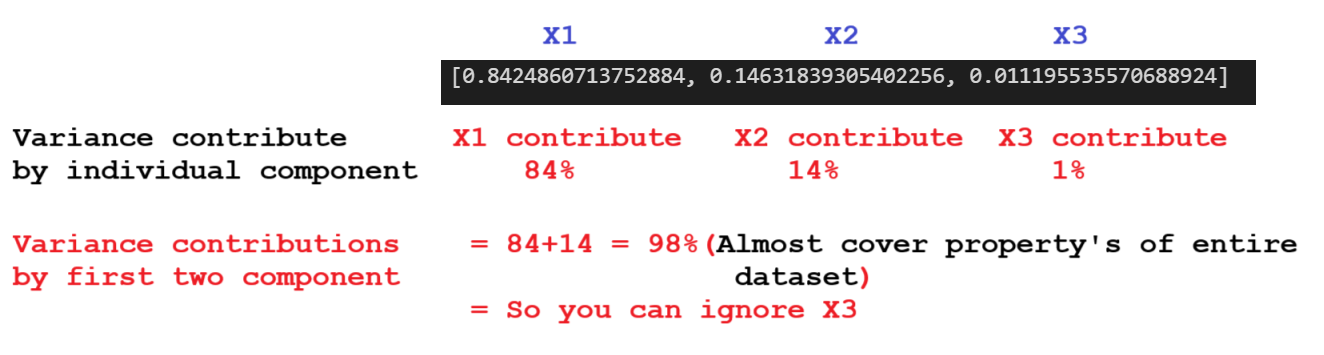

### Method -3 
Scikit lern

In [11]:
pca = PCA(n_components = 3)
X3D = pca.fit_transform(X)

# Print the explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Choosing the Right Number of Dimensions
def choose_number_of_dimensions(variance_ratio, threshold=0.95):
    """
    Choose the number of dimensions based on the cumulative explained variance.

    Parameters:
    eigenvalues (array-like): Eigenvalues of the covariance matrix.
    threshold (float): Cumulative explained variance threshold to reach.

    Returns:
    int: Number of dimensions to keep.
    """
    cumulative_variance = np.cumsum(variance_ratio)
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    return n_components
NumOfDimentions = choose_number_of_dimensions(pca.explained_variance_ratio_, threshold=0.95)
print("Number of dimensions to keep:", NumOfDimentions)


Explained variance ratio: [0.84248607 0.14631839 0.01119554]
Number of dimensions to keep: 2


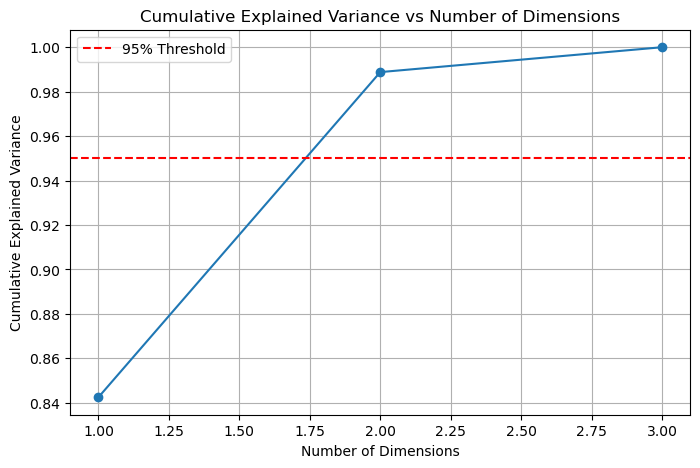

In [12]:
# Plot Explained variance as a function of the number of dimensions
def plot_explained_variance(pca):
    """
    Plot the explained variance as a function of the number of dimensions.

    Parameters:
    pca (PCA object): Fitted PCA object.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
             np.cumsum(pca.explained_variance_ratio_), marker='o')
    plt.title('Cumulative Explained Variance vs Number of Dimensions')
    plt.xlabel('Number of Dimensions')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid()
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
    plt.legend()
    plt.show()
plot_explained_variance(pca)

### Pass ratio of variance you wish to preserve instade of n componentes


In [13]:
# Pass ratio of variance you wish to preserve instade of n componentes
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

NameError: name 'X_train' is not defined

### PCA for Compression

**Just like inverse tranformataions.**

It is also possible to ***decompress the reduced dataset*** back to 784 dimensions by
applying the inverse transformation of the PCA projection. Of course this won’t give
you back the original data, since the projection lost a bit of information (within the
5% variance that was dropped), but it will likely be quite close to the original data.

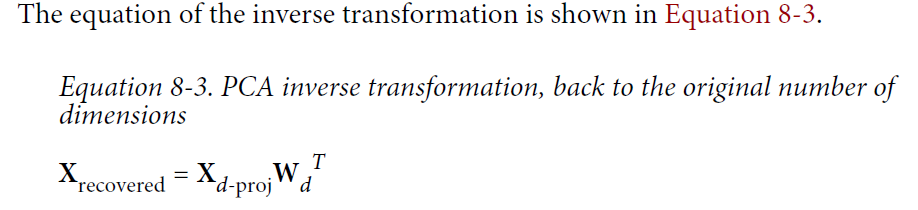

In [ ]:
pca = PCA(n_components = 154)
X_reduced = pca.fit_transform(X_train)
X_recovered = pca.inverse_transform(X_reduced)

### Randomized PCA

If you set the svd_solver hyperparameter to "randomized", Scikit-Learn uses a stochastic algorithm called Randomized PCA that quickly finds an approximation of the first d principal components.

Its computational complexity is O(m × d2) + O(d3), instead of O(m × n2) + O(n3) for the full SVD approach, so it is dramatically faster than full SVD when d is much smaller than n

**rnd_pca = PCA(n_components=154, svd_solver="randomized")**

**X_reduced = rnd_pca.fit_transform(X_train)**

### Incremental PCA

**One problem** with the **preceding implementations of PCA** is that they **require the whole training set** to fit in memory in order for the algorithm to run. 

Fortunately, **Incremental PCA (IPCA) algorithms** have been developed: 

**split the training set into mini-batches** and feed an IPCA algorithm one mini-batch at a time.

***Note that you must call the partial_fit() method with each mini-batch rather than the fit() method with the whole training set***

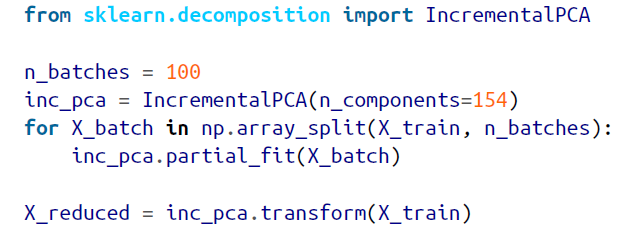


### Kernel PCA

TODO

### Locally Linear Embedding (LLE)

another very powerful nonlinear dimensionality reduction (NLDR) technique. It is a Manifold Learning technique that does not rely on projections like the previous algorithms.

TODO

### Other Dimensionality Reduction Techniques

1. ***Multidimensional Scaling (MDS)*** reduces dimensionality while trying to preserve    the distances  
   between the instances.

2. ***Isomap*** creates a graph by connecting each instance to its nearest neighbors, then reduces 
   dimensionality while trying to preserve the geodesic distances9 between the instances.

3. ***t-Distributed Stochastic Neighbor Embedding (t-SNE)*** reduces dimensionality while trying to keep 
   similar instances close and dissimilar instances apart.

4. ***Linear Discriminant Analysis (LDA)*** is actually a classification algorithm, but during training it 
   learns the most discriminative axes between the classes, and these axes can then be used to define a hyperplane onto which to project the data.